SpatialFusion can only be used on H&E images directly without spatial transcriptomics to uncover niches. Because the pre-trained model uses both gene expression and H&E, the niches are 'molecularly-informed' even if run on H&E only. 

In this tutorial we will show how you can run the SpatialFusion pipeline on an H&E image.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [2]:
# Standard library
import logging
import os
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import torch
import cv2
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms
from skimage.color import separate_stains, hed_from_rgb

# Warning filters
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
adata = sc.read_h5ad('data/tutadata_subset.h5ad')

# Step 0: Run nuclei segmentation

The minimum input to SpatialFusion is the UNI/Virchow embeddings of each of the patches centered around cells, as the method is single-cell resolution. This means that to construct the UNI/Virchow embeddings you need the x and y coordinates of the cell centroids. To obtain them, you can just run the nuclei segmentation method of your choice. Cellpose is an easy and good option (https://www.cellpose.org/).

Here we show an example running Cellpose on the tutorial WSI crop.

##### THIS FOLLOWING CELL IS JUST AN EXAMPLE OF HOW TO RUN NUCLEI SEGMENTATION BUT YOU WILL HAVE TO HAVE CELLPOSE INSTALLED TO RUN IT. YOU CAN JUST START AT THE FOLLOWING CELL WITH THE PROVIDED SEGMENTATION RESULTS.

In [ ]:
from cellpose import models

use_gpu = torch.cuda.is_available()

model_nuclei = models.CellposeModel(gpu=use_gpu)
model_nuclei.pretrained_model = 'nuclei'

img_path = 'data/wsi_crop.ome.tif'

# --- Load image ---
image = tifffile.imread(img_path)

# --- Ensure RGB ---
if image.ndim == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
elif image.shape[-1] > 3:
    image = image[..., :3]

# Convert to float in [0,1] (IMPORTANT for skimage)
image_float = image.astype(np.float32) / 255.0

# --- H&E stain separation ---
hed = separate_stains(image_float, hed_from_rgb)

# Hematoxylin channel (nuclei)
hematoxylin = hed[..., 0]

# --- Normalize for Cellpose ---
# Invert because nuclei should be bright for Cellpose
hematoxylin = -hematoxylin

# Rescale to 0–1
hematoxylin -= hematoxylin.min()
hematoxylin /= (hematoxylin.max() + 1e-8)

# Convert to 8-bit (optional but often helpful)
hematoxylin_uint8 = (hematoxylin * 255).astype(np.uint8)

print("Running Cellpose on hematoxylin channel...")

nuclei_labels = model_nuclei.eval(
    hematoxylin_uint8,
    channels=[0, 0],  # NOW this is correct
    diameter=25,
)[0]

tifffile.imwrite(
    '../tutorials/data/nuclei_segmentation_mask.tif',
    nuclei_labels.astype(np.uint16)
)

We provide the segmentation mask so you can start from here. We can visualize the results of the nuclei segmentation.

In [3]:
# --- Load image ---
img_path = 'data/wsi_crop.ome.tif'
image = tifffile.imread(img_path)

In [4]:
mask_path = 'data/nuclei_segmentation_mask.tif'
nuclei_labels = tifffile.imread(mask_path)

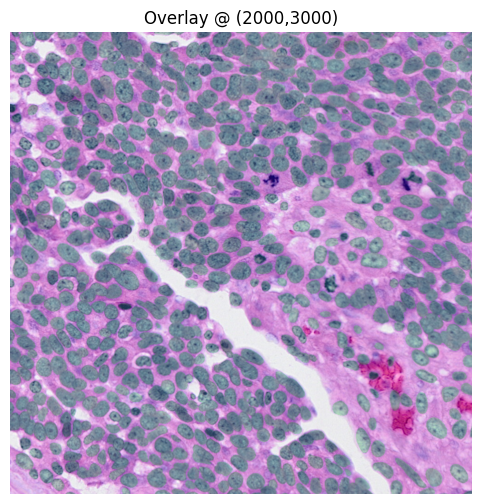

In [5]:
# --- Define crop location ---
x, y = 2000, 3000   # top-left corner
h, w = 1000, 1000

orig_crop = image[y:y+h, x:x+w]
labels_crop = nuclei_labels[y:y+h, x:x+w]

# --- Overlay ---
mask = labels_crop > 0

overlay = orig_crop.copy()
overlay[mask] = [0, 255, 0]

alpha = 0.2
blended = cv2.addWeighted(overlay, alpha, orig_crop, 1 - alpha, 0)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.imshow(blended)
plt.title(f"Overlay @ ({x},{y})")
plt.axis("off")
plt.show()

# Step 1: Run UNI on the cell patches

In [6]:
from skimage.measure import regionprops

# Compute region properties
regions = regionprops(nuclei_labels)

# Extract centroids
data = []
for r in regions:
    y, x = r.centroid   # NOTE: (row, col) = (y, x)
    data.append({
        "cell_id": r.label,
        "x": x,
        "y": y
    })

segm_coords = pd.DataFrame(data)

print(segm_coords.head())

   cell_id           x          y
0        1   32.710288  16.958848
1        2  285.796687   8.944277
2        3  337.133238   9.134670
3        4  547.253927   7.931937
4        5  645.047767  12.844237


Here we are running UNI, as this is the H&E-only pretrained version we provide. We will extend the framework to accommodate other H&E FM in the future. If there is a FM you would like integrated, don't hesitate to open an issue on the Github repository.

In [7]:
PATH_UNI_WEIGHTS = pl.Path('/ewsc/yatesjos/Broad_SpatialFoundation/UNI/pytorch_model.bin')

In [11]:
def load_UNI_model(model_path: str, device: str = "cuda"):
    timm_kwargs = {
        'model_name': 'vit_giant_patch14_224',
        'img_size': 224,
        'patch_size': 14,
        'depth': 24,
        'num_heads': 24,
        'init_values': 1e-5,
        'embed_dim': 1536,
        'mlp_ratio': 2.66667 * 2,
        'num_classes': 0,
        'no_embed_class': True,
        'mlp_layer': timm.layers.SwiGLUPacked,
        'act_layer': torch.nn.SiLU,
        'reg_tokens': 8,
        'dynamic_img_size': True
    }

    model = timm.create_model(pretrained=False, **timm_kwargs)
    model.load_state_dict(torch.load(model_path, map_location="cpu"), strict=True)
    model.eval().to(device)

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406),
                             std=(0.229, 0.224, 0.225)),
    ])
    return model, transform


def embed_UNI(wsi, cell_names, he_coords, output_dir, model_path, batch_size = 128, device = "cuda"):

    print('Load UNI model')
    model, transform = load_UNI_model(model_path, device)

    os.makedirs(output_dir, exist_ok=True)

    embeddings = []
    cell_ids = []
    
    batch_imgs = []
    batch_ids = []
    
    print(f"Embedding {len(he_coords)} image patches in batches of {batch_size}...")
    for cid, (x, y) in tqdm(zip(cell_names, he_coords), total=len(cell_names)):
        x, y = int(x), int(y)
        x0, x1 = x - 128, x + 128
        y0, y1 = y - 128, y + 128
    
        pad_x0 = max(0, -x0)
        pad_x1 = max(0, x1 - wsi.shape[1])
        pad_y0 = max(0, -y0)
        pad_y1 = max(0, y1 - wsi.shape[0])
    
        patch = np.pad(
            wsi[max(0, y0):min(wsi.shape[0], y1), max(0, x0):min(wsi.shape[1], x1)],
            ((pad_y0, pad_y1), (pad_x0, pad_x1), (0, 0)),
            mode="constant"
        )
    
        if patch.shape[:2] != (256, 256):
            continue
    
        tensor_img = transform(Image.fromarray(patch))
        batch_imgs.append(tensor_img)
        batch_ids.append(cid)
    
        if len(batch_imgs) == batch_size:
            img_tensor = torch.stack(batch_imgs).to(device)
    
            with torch.inference_mode(), torch.autocast(device_type=device, dtype=torch.float16):
                batch_embs = model(img_tensor).to(torch.float16).cpu().numpy()
    
            embeddings.extend(batch_embs)
            cell_ids.extend(batch_ids)
            batch_imgs.clear()
            batch_ids.clear()
    
    # Final batch (if any)
    if batch_imgs:
        img_tensor = torch.stack(batch_imgs).to(device)
        with torch.inference_mode(), torch.autocast(device_type=device, dtype=torch.float16):
            batch_embs = model(img_tensor).to(torch.float16).cpu().numpy()
        embeddings.extend(batch_embs)
        cell_ids.extend(batch_ids)

    # Save embedding matrix
    df = pd.DataFrame(embeddings, index=cell_ids)
    df.to_parquet(f"{output_dir}/UNI_crop.parquet")
    print(f"Saved {len(df)} embeddings to {output_dir}/UNI_crop.parquet")    

In [9]:
output_dir = 'data/'
device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = PATH_UNI_WEIGHTS

cell_names = segm_coords.cell_id.values.astype(str)
he_coords = segm_coords[['x','y']].values

In [10]:
embed_UNI(
    image,
    cell_names,
    he_coords,
    output_dir,
    model_path,
    batch_size = 512,
    device = device
)

Load UNI model
Embedding 41327 image patches in batches of 512...


  0%|          | 0/41327 [00:00<?, ?it/s]

Saved 41327 embeddings to data//UNI.parquet


# Step 2: Embed using SpatialFusion (H&E)

In [12]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding

In [13]:
output_dir = 'data/'

In [14]:
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI_crop.parquet')

In [15]:
ae_model_path = pl.Path('../data/checkpoint_dir_ae/spatialfusion-ae-uni-scgpt.pt')
### HERE IT'S IMPORT TO POINT TO THE H&E ONLY VARIANT OF SPATIALFUSION
gcn_model_path =  pl.Path('../data/checkpoint_dir_gcn/spatialfusion-he-gcn-uni-scgpt.pt')

Now we build a fake adata just to keep the format consistent with the multimodal version. It needs to have the coordinates of the cells in `adata.obsm['spatial']` and consistent indexing. 

In [19]:
adata = sc.AnnData(uni_df)
# we use the segmentation derived centroids
adata.obsm['spatial'] = segm_coords[['x','y']].values

/ewsc/yatesjos/spatialfusion_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [20]:
# can run this for several samples at a time
# the second input is None here in H&E only
ae_inputs_by_sample = {
    'crop': AEInputs(adata=adata, z_he=uni_df, z_rna=None),
}

# this uses the average version
emb_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    device=device,
    combine_mode="z1", # IMPORTANT! z1= H&E only mode
    spatial_key='spatial',
    celltype_key='major_celltype',
    ae_model_path=ae_model_path,
    gcn_model_path=gcn_model_path,
    save_ae_dir=None,  # optional
)

Running GCN inference: 100%|██████████████████████| 1/1 [00:10<00:00, 10.55s/it]


In [29]:
emb_df.columns = emb_df.columns.astype(str)

adata.obsm['SpatialFusion'] = emb_df.set_index('cell_id').loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]

## Now we cluster to obtain niches

In [30]:
sc.pp.neighbors(adata, use_rep='SpatialFusion')

In [49]:
sc.tl.leiden(adata, resolution=0.03, flavor="igraph", n_iterations=2)
# Display number of clusters
adata.obs.leiden.value_counts()

leiden
0    27193
3     6650
2     4608
4     2542
1      334
Name: count, dtype: int64

In [50]:
adata.obs['X_coord'] = adata.obsm['spatial'][:,0]
adata.obs['Y_coord'] = adata.obsm['spatial'][:,1]

We can now visualize the niches in space

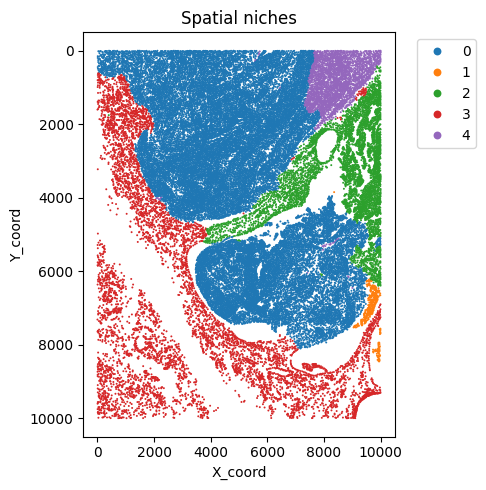

In [51]:
adata.obs['leiden'] = adata.obs['leiden'].astype(str).astype('category')
plt.style.use('default')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# --- Plot 1: Spatial niches ---
sns.scatterplot(
    ax=ax,
    data=adata.obs,
    x='X_coord', y='Y_coord',
    hue='leiden',
    palette='tab10',
    s=2,
    linewidth=0
)
ax.invert_yaxis()
ax.set_title("Spatial niches")
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    scatterpoints=1,
    markerscale=4
)

plt.tight_layout()

We can also visualize the overlay on the H&E

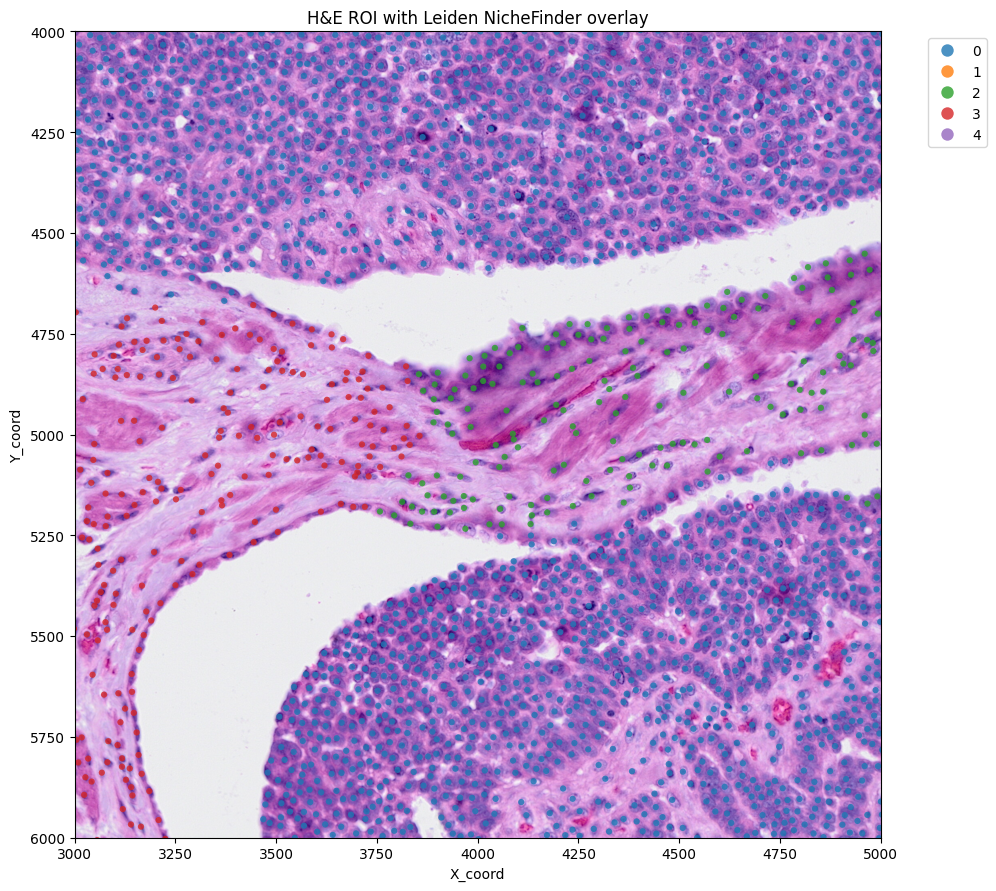

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Region of interest in H&E pixel space
xlim = (3000, 5000)
ylim = (4000, 6000)

x0, x1 = xlim
y0, y1 = ylim

# --- Crop ROI from the WSI
roi = image[y0:y1, x0:x1, :]  # note: numpy indexing is [row=y, col=x]

fig, ax = plt.subplots(figsize=(10, 10))

# Show the H&E ROI
ax.imshow(roi, origin="upper", extent=(x0, x1, y1, y0))  
# ^ extent maps the array coords into the same coordinate system as X_he, Y_he
#   origin="upper" keeps top-left = (0,0)

# Overlay scatter using aligned coords
sns.scatterplot(
    data=adata.obs,
    x="X_coord", y="Y_coord",
    hue="leiden",          # categorical cluster
    palette="tab10",
    s=20, alpha=0.8,
    ax=ax,
    linewidth=0
)

# Match the crop window
ax.set_xlim(x0, x1)
ax.set_ylim(y1, y0)  # because origin="upper" flips Y

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    scatterpoints=1,       # how many points to show per entry
    markerscale=2          # scale factor for the legend markers
)
ax.set_title("H&E ROI with Leiden NicheFinder overlay")

plt.tight_layout()
plt.show()
